In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from baselines.Pan_Tompkins import ECGProcessor

from agents.sac import SAC
from agents.ppo import PPO
from env import SMF

# Pan-Tompkins

In [2]:
dir = os.path.join('data', 'peak')
with os.scandir(dir) as it:
    data_files = [entry.name for entry in it if entry.is_file()]
data_files = sorted(data_files, key=lambda x: int(x.split('.')[0]))
split_index = int(len(data_files)*0.7)

train_data_files, test_data_files = data_files[:split_index], data_files[split_index:]
num_train, num_test = len(train_data_files), len(test_data_files)

In [3]:
def normalize(x):
    min, max = x.min(), x.max()
    scale, bias = (max - min)/2, (max + min)/2
    return (x-bias)/scale

whole_signal = []
whole_peaks = []
for idx in range(num_test):
    data_file_name = test_data_files[idx]
    signal_pth = os.path.join('data', 'signal', data_file_name)
    peak_pth = os.path.join('data', 'peak', data_file_name)
    signal = normalize(np.load(signal_pth).astype(np.float32))
    peaks = np.load(peak_pth).astype(np.float32)

    whole_signal.append(signal)
    whole_peaks.append(peaks+idx*250)

    
    # plt.plot(signal) # sampling rate should be 100
    # plt.show()
    #print(peaks)
    # break

# Convert whole_signal to a single array
whole_signal_array = np.concatenate(whole_signal)
whole_peaks_array = np.concatenate(whole_peaks)

In [4]:
def process_ecg(ecg_signal, fs=200):
    """
    Process ECG signal and detect PQRST complexes
    Parameters:
    ecg_signal: Raw ECG signal
    fs: Sampling frequency in Hz
    Returns:
    Dictionary containing detected points and filtered signals
    """
    processor = ECGProcessor(fs=fs)
    # Detect QRS complexes
    qrs_peaks, filtered_signal, mwi, threshold = processor.find_qrs_peaks(ecg_signal)
    
    return qrs_peaks
 
results = process_ecg(whole_signal_array, fs=200)
results = np.array(results)

def reward_function_balanced(pks_preds, pks_gts, tolerance=5):
    # use broadcast if preds=[a, b, c, d], preds_correct=[True, False, True, True]
    preds_correct = np.any(np.abs(pks_preds.reshape((-1, 1)) - pks_gts.reshape((1, -1))) < tolerance, axis=1)
    num_preds, num_gts = len(pks_preds), len(pks_gts)
    TP = preds_correct.sum()
    FP = num_preds - TP
    FN = num_gts - TP

    TP = TP/num_gts if num_gts>0 else 0
    FN = FN/num_gts if num_gts>0 else 0
    FP = FP/num_preds if num_preds>0 else 0

    reward = 10 * TP - 5 * FP - 5 * FN
    return reward, TP, FP, FN

TP = np.zeros(50)
FP = np.zeros(50)
FN = np.zeros(50)

for delay in range(0,50):
    pks_preds = results + delay
    pks_gts = whole_peaks_array
    _, TP[delay], FP[delay], FN[delay] = reward_function_balanced(pks_preds, pks_gts, tolerance=5)

precision, recall = TP / (TP + FP), TP / (TP + FN)
F1 = 2 * TP / (2 * TP + FP + FN)

max_F1_PT= np.max(F1)  # Maximum value
delay_PT = np.argmax(F1)  # Index of the maximum value

print("Max PT F1:", max_F1_PT)
print("Max Delay:", delay_PT)
print('preicion:', precision[delay_PT])
print('recall:', recall[delay_PT])

preds_pt = results + delay_PT

Max PT F1: 0.5692500169067424
Max Delay: 0
preicion: 0.6675522423569531
recall: 0.4961832061068702


# SMF

In [5]:
from matplotlib.lines import Line2D

def validate(env, agent):
    dir = os.path.join('data', 'peak')
    with os.scandir(dir) as it:
        data_files = [entry.name for entry in it if entry.is_file()]
    data_files = sorted(data_files, key=lambda x: int(x.split('.')[0]))
    split_index = int(len(data_files)*0.7)
    test_data_files = data_files[split_index:]

    ecg_list, sig_list, peaks_list, preds_list = [], [], [], []
    TP, FP, FN = 0, 0, 0
    for idx in range(env.num_test):
        data_file_name = test_data_files[idx]
        signal_pth = os.path.join('data', 'signal', data_file_name)
        peak_pth = os.path.join('data', 'peak', data_file_name)
        ecg = np.load(signal_pth).astype(np.float32)
        peaks = np.load(peak_pth).astype(np.float32)
        ecg_list += ecg.tolist()
        peaks_list += (peaks + len(ecg) * idx).tolist()

        obs, info = env.reset(seed = 0, status = 'test', idx = idx)
        done = False
        while not done:
            if agent.__class__.__name__ == 'SAC':
                _, _, act = agent.actor.get_action(torch.Tensor(obs).unsqueeze(0).to(agent.device))
            elif agent.__class__.__name__ == 'PPO':
                _, _, _, _, act = agent.agent.get_action_and_value(torch.Tensor(obs).unsqueeze(0).to(agent.device))
            else:
                raise NotImplementedError()
            
            act = act.squeeze(0).detach().cpu().numpy()
            obs, rew, term, trun, info = env.step(act, status = 'test')
            if term or trun:
                sig = env.state.tolist()
                sig_list += sig
                preds_list += (info['preds'] + len(ecg) * idx).tolist()
                TP += info['TP']
                FP += info['FP']
                FN += info['FN']
                break
    return np.array(ecg_list), np.array(sig_list), np.array(peaks_list, dtype=np.int32), np.array(preds_list, dtype=np.int32), TP, FP, FN


def plot_sig(ecg, sig, peaks, preds, preds_pt, fs=200, xlim=(50, 60)):
    ecg, sig = normalize(ecg), normalize(sig)

    fig, axs = plt.subplots(1, 3, figsize=(14, 3), dpi=600, gridspec_kw={'width_ratios': [6, 1, 6]})
    plt.rcParams['lines.linewidth'] = 2


    for peak in peaks:
        axs[0].axvline(x=peak/fs, color='r', linestyle='--')
    axs[0].plot(np.arange(len(ecg))/fs, ecg)
    axs[0].plot(preds_pt/fs, ecg[preds_pt], "^", color='peru', markersize=10, markeredgewidth=3, fillstyle='none')
    axs[0].set_xlim(xlim)
    axs[0].set_ylim([-0.8, 0.6])
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_title('Original arrhythmia ECG', fontsize=16)
    legend_elements = [
        Line2D([0], [0], color='r', linestyle='--', label='True'),
        Line2D([0], [0], marker='^', linestyle=' ', color='peru', markersize=10, markeredgewidth=3, fillstyle='none', label="Pan-Tompkins"),
    ]
    legend = axs[0].legend(handles=legend_elements, loc='lower left', fontsize=16, ncol=2, frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_boxstyle("Square")


    axs[1].annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5),
                    arrowprops=dict(facecolor='black', shrinkA=0, shrinkB=0))
    axs[1].text(0.5, 0.6, "SMF", fontsize=16, ha='center', va='center', color='black', rotation=0)
    axs[1].set_xlim(0, 1)
    axs[1].set_ylim(0, 1)
    axs[1].axis('off')

    for peak in peaks:
        axs[2].axvline(x=peak/fs, color='r', linestyle='--')
    axs[2].plot(np.arange(len(sig))/fs, sig)
    axs[2].plot(preds/fs, sig[preds], "x", color='magenta', markersize=10, markeredgewidth=2)
    axs[2].set_xlim(xlim)
    axs[2].set_xticks([])
    axs[2].set_yticks([])
    axs[2].set_title('After SMF', fontsize=16)
    axs[2].legend(['True', "Pan-Tompkins", "SMF-SAC"])

    legend_elements = [
        Line2D([0], [0], color='r', linestyle='--', label='True'),
        Line2D([0], [0], marker='x', linestyle=' ', color='magenta', markersize=10, markeredgewidth=2, label="SMF-SAC")
    ]
    legend = axs[2].legend(handles=legend_elements, loc='lower left', fontsize=16, ncol=2, frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_boxstyle("Square")

    fig.text(0.01, 0.97, 'b', fontsize=20, fontweight='bold', va='top', ha='left')
    fig.tight_layout()
    plt.show()

In [6]:
env_sac = SMF(render=False, eps_len=1, template_len = 12)
agent_sac = SAC(env_sac, ckpt_path = 'saved/eps_len_1/SAC_best.pt', use_tb=False)

env_ppo = SMF(render=False, eps_len=1, template_len = 8)
agent_ppo = PPO(env_ppo, ckpt_path = 'saved/eps_len_1/PPO_best.pt', use_tb=False)


ecg, sig, peaks, preds, TP, FP, FN = validate(env_ppo, agent_ppo)
precision, recall = TP / (TP + FP), TP / (TP + FN)
F1 = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
print('For PPO:')
print(f'precision={precision:.4f}, recall={recall:.4f}, F1={F1:.4f}')

ecg, sig, peaks, preds, TP, FP, FN = validate(env_sac, agent_sac)
precision, recall = TP / (TP + FP), TP / (TP + FN)
F1 = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
print('For SAC:')
print(f'precision={precision:.4f}, recall={recall:.4f}, F1={F1:.4f}')

episode length is 1
Running on cuda
Current time: _03_27_2026_14_02
Training from the checkpoint in {self.ckpt_path}
episode length is 1
Running on cuda
Current time: _03_27_2026_14_02
Training from the checkpoint in {self.ckpt_path}
For PPO:
precision=0.9073, recall=0.9211, F1=0.9141
For SAC:
precision=0.8978, recall=0.9160, F1=0.9068


episode length is 3
Running on cuda
Current time: _03_27_2026_14_02
Training from the checkpoint in {self.ckpt_path}
episode length is 3
Running on cuda
Current time: _03_27_2026_14_02
Training from the checkpoint in {self.ckpt_path}
For PPO:
precision=0.9446, recall=0.9542, F1=0.9494
For SAC:
precision=0.9543, recall=0.9567, F1=0.9555


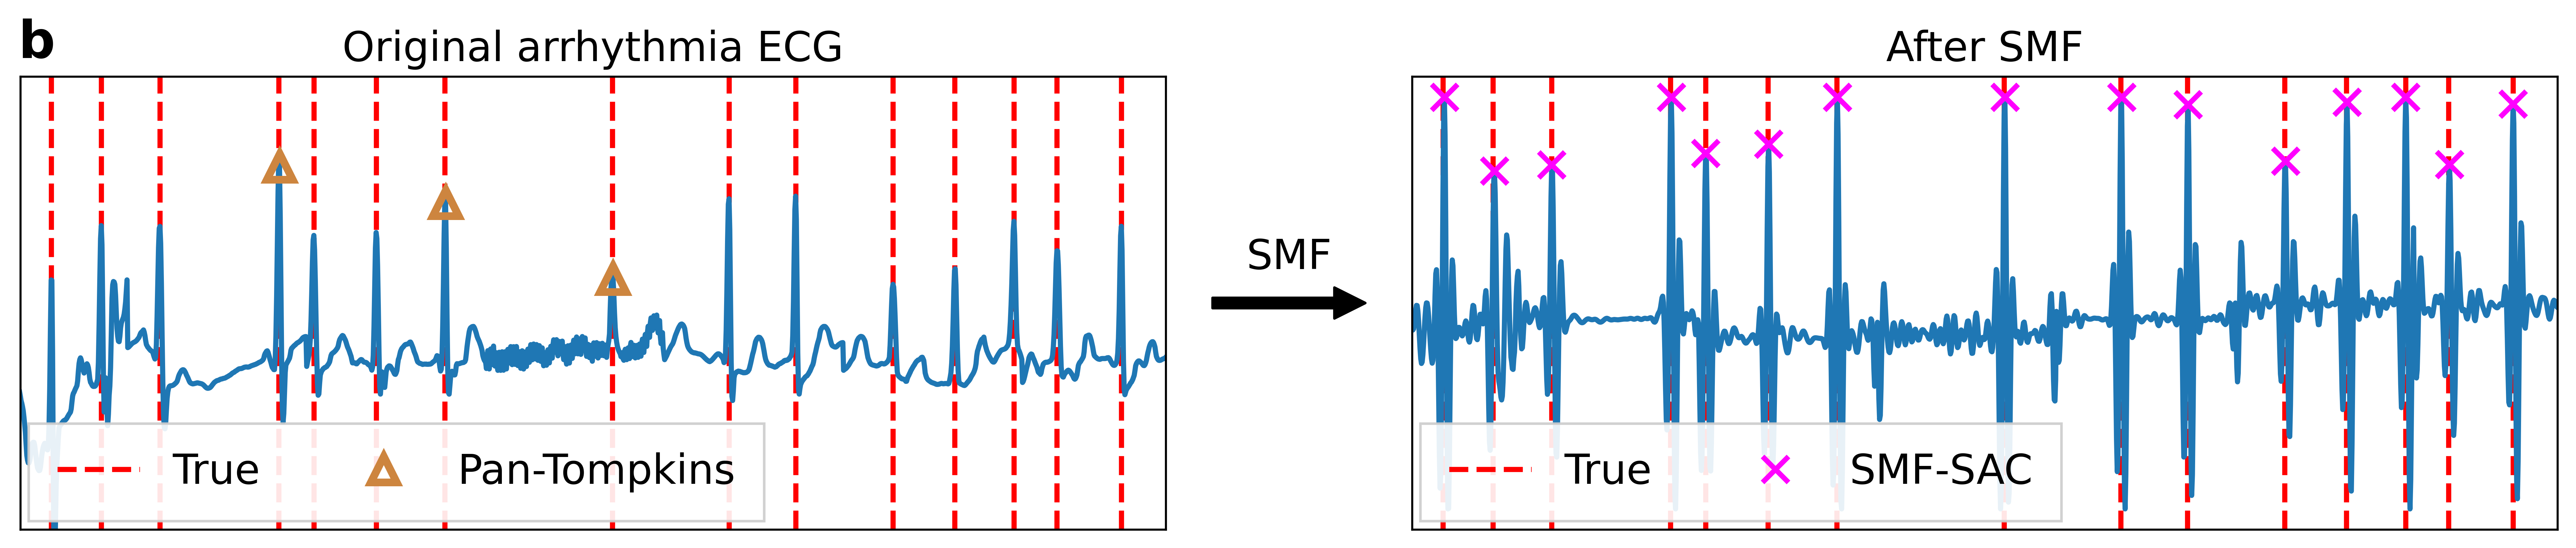

In [7]:
env_sac = SMF(render=False, eps_len=3, template_len = 12)
agent_sac = SAC(env_sac, ckpt_path = 'saved/eps_len_3/SAC_best.pt', use_tb=False)

env_ppo = SMF(render=False, eps_len=3, template_len = 8)
agent_ppo = PPO(env_ppo, ckpt_path = 'saved/eps_len_3/PPO_best.pt', use_tb=False)

ecg, sig, peaks, preds, TP, FP, FN = validate(env_ppo, agent_ppo)
precision, recall = TP / (TP + FP), TP / (TP + FN)
F1 = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
print('For PPO:')
print(f'precision={precision:.4f}, recall={recall:.4f}, F1={F1:.4f}')

ecg, sig, peaks, preds, TP, FP, FN = validate(env_sac, agent_sac)
precision, recall = TP / (TP + FP), TP / (TP + FN)
F1 = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
print('For SAC:')
print(f'precision={precision:.4f}, recall={recall:.4f}, F1={F1:.4f}')

plot_sig(ecg, sig, peaks, preds, preds_pt, xlim=(43, 51))